# **혐오발언 종류 분류하기**

K-MHaS 기반 문장 분류
기본: 멀티클래스 / 보너스: 멀티레이블
이번 과제는 K-MHaS(Korean Multi-label Hate Speech) 데이터셋을 활용하여 한국어 온라인 뉴스 댓글의 혐오표현 여부를 분류하는 프로젝트입니다.
기본 과제는 멀티클래스(단일 라벨)로 수행하며, 보너스 과제는 멀티레이블(복수 라벨 동시 예측)로 확장합니다.
혐오·차별 표현이 포함될 수 있으므로 데이터 취급 시 유의해 주시기 바랍니다.

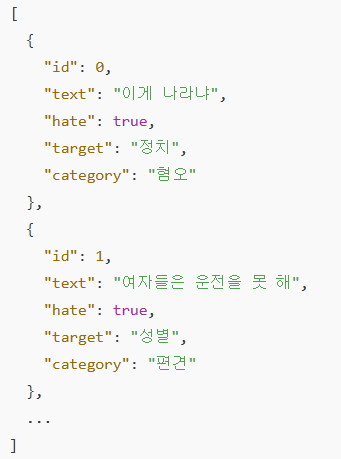

필드 설명

text: 분석 대상

hate: 혐오 여부(True/False)

target: 혐오 대상(예: 성별, 정치, 지역 등)

category: 혐오 종류(예: 혐오, 편견, 차별 등)


⇒ 과제 목표: 혐오 표현 여부 (hate: true/false) 분류

label : 혐오 유형 (0~7 → 혐오, 8 → 비혐오)

-----------

In [1]:
!pip install transformers
!pip install datasets

In [9]:
# (기존 파일 삭제 후) Raw 링크로 재다운로드
!rm -f kmhas_train.txt

In [12]:
!wget https://raw.githubusercontent.com/adlnlp/K-MHaS/refs/heads/main/data/kmhas_train.txt

--2025-09-02 02:52:40--  https://raw.githubusercontent.com/adlnlp/K-MHaS/refs/heads/main/data/kmhas_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6845463 (6.5M) [application/octet-stream]
Saving to: ‘kmhas_train.txt’

kmhas_train.txt     100%[===================>]   6.53M  --.-KB/s    in 0.07s   

2025-09-02 02:52:40 (90.0 MB/s) - ‘kmhas_train.txt’ saved [6845463/6845463]



In [13]:
import pandas as pd

df = pd.read_csv("kmhas_train.txt", sep="\t")
print(df.head())
print(df.columns)


                                    document label
0                         자한당틀딱들.. 악플질 고만해라.   2,4
1                    정치적으로 편향된 평론한은 분은 별로...     8
2  적당히좀 쳐먹지.그랬냐??? 안그래도 문재인 때문에 나라 엉망진창인데...     2
3                            안서는 아재들 풀발기 ㅋㄲㅋ     4
4                                   우와 ㅋ 능력자     8
Index(['document', 'label'], dtype='object')


In [14]:
# label 값이 "2,3" 같이 여러 개 들어 있을 수 있음
# → 멀티클래스 분류를 할 때는 보통 "첫 번째 label"만 사용하거나
#   "multi-label classification"으로 풀 수 있음
# 여기서는 단일 다중클래스(0~8) 기준으로 간단히 "첫 label만 사용"
df["label"] = df["label"].apply(lambda x: int(str(x).split(",")[0]))

print(df.head())


                                    document  label
0                         자한당틀딱들.. 악플질 고만해라.      2
1                    정치적으로 편향된 평론한은 분은 별로...      8
2  적당히좀 쳐먹지.그랬냐??? 안그래도 문재인 때문에 나라 엉망진창인데...      2
3                            안서는 아재들 풀발기 ㅋㄲㅋ      4
4                                   우와 ㅋ 능력자      8


In [15]:
# 데이터 확인
print(df.shape)      # (행 개수, 열 개수)
print(df.columns)    # ['document', 'label']
print(df['label'].unique())  # 라벨 값 확인
df.head()

(78977, 2)
Index(['document', 'label'], dtype='object')
[2 8 4 3 0 1 5 7 6]


,document,label
0,자한당틀딱들.. 악플질 고만해라.,2
1,정치적으로 편향된 평론한은 분은 별로...,8
2,적당히좀 쳐먹지.그랬냐??? 안그래도 문재인 때문에 나라 엉망진창인데...,2
3,안서는 아재들 풀발기 ㅋㄲㅋ,4
4,우와 ㅋ 능력자,8


In [16]:
# 라벨 정리

df["label"] = df["label"].astype(str).apply(lambda x: int(x.split(",")[0]))

In [17]:
# 데이터 분할
from sklearn.model_selection import train_test_split

X = df["document"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2025, stratify=y
)


In [18]:
# 벡터화
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [19]:
# Logistic Regression(기본 분류모델 학습)
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=200, C=2, solver="lbfgs", multi_class="multinomial")
clf.fit(X_train_vec, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(C=2, max_iter=200, multi_class='multinomial')

In [20]:
# 평가
from sklearn.metrics import classification_report

y_pred = clf.predict(X_test_vec)
print(classification_report(y_test, y_pred, digits=3))


              precision    recall  f1-score   support

           0      0.668     0.362     0.469      1454
           1      0.735     0.386     0.506      1235
           2      0.676     0.430     0.526      1471
           3      0.554     0.250     0.345      1555
           4      0.633     0.346     0.448       713
           5      0.516     0.191     0.279       491
           6      0.000     0.000     0.000        25
           7      0.609     0.381     0.469       270
           8      0.667     0.931     0.777      8582

    accuracy                          0.662     15796
   macro avg      0.562     0.364     0.424     15796
weighted avg      0.654     0.662     0.625     15796



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
label_map = {
    0: "출신 차별",
    1: "외모 차별",
    2: "정치성향 차별",
    3: "혐오 욕설",
    4: "연령 차별",
    5: "성 차별",
    6: "인종 차별",
    7: "종교 차별",
    8: "비혐오"
}

In [24]:
# 예시 문장
test_sentences = [
    "짱깨들 때문에 나라가 망한다",
    "노인네들 너무 느려서 짜증나",
    "문재인 정권은 정말 한심하다",
    "이 영화 정말 재밌다",
    "빨갱이 놈들"
]

test_vec = vectorizer.transform(test_sentences)
pred_labels = clf.predict(test_vec)

for sent, label in zip(test_sentences, pred_labels):
    print(f"문장: {sent}")
    print(f"예측 라벨: {label_map[label]} ({label})")
    print()


문장: 짱깨들 때문에 나라가 망한다
예측 라벨: 출신 차별 (0)

문장: 노인네들 너무 느려서 짜증나
예측 라벨: 비혐오 (8)

문장: 문재인 정권은 정말 한심하다
예측 라벨: 비혐오 (8)

문장: 이 영화 정말 재밌다
예측 라벨: 비혐오 (8)

문장: 빨갱이 놈들
예측 라벨: 정치성향 차별 (2)



--------